In [17]:
import pandas as pd
from matplotlib.pyplot import *
from numpy import *

In [18]:
df = pd.read_csv("Data.csv")
err = 32 # zero error
df["X1"] = df["X1"] - err
df["X2"] = df["X2"] - err
df["L"] = df["L"] - err
df

,v,L,X1,X2,n
0,0.5,748,199,568,2
1,1.0,695,57,613,4
2,1.5,798,123,742,6
3,2.0,858,171,816,8
4,2.5,831,128,801,10
5,3.0,873,165,848,12
6,3.5,877,169,859,14
7,4.0,873,201,624,10
8,4.5,887,170,543,10
9,5.0,869,186,521,10


In [19]:
df["lambda"] = 2*(df["X2"]-df["X1"])/(df["n"]-1) #mm
df["V"] = df["lambda"] * df['v'] #m/s
df

,v,L,X1,X2,n,lambda,V
0,0.5,748,199,568,2,738.000000,369.000000
1,1.0,695,57,613,4,370.666667,370.666667
2,1.5,798,123,742,6,247.600000,371.400000
3,2.0,858,171,816,8,184.285714,368.571429
4,2.5,831,128,801,10,149.555556,373.888889
5,3.0,873,165,848,12,124.181818,372.545455
6,3.5,877,169,859,14,106.153846,371.538462
7,4.0,873,201,624,10,94.000000,376.000000
8,4.5,887,170,543,10,82.888889,373.000000
9,5.0,869,186,521,10,74.444444,372.222222


In [20]:
print("mean",mean(df['V']))
print("sd",var(df["V"])**0.5)

mean 371.8833122433123
sd 2.094863763022299


Text(0, 0.5, 'wavelength $\\lambda $ (mm)')

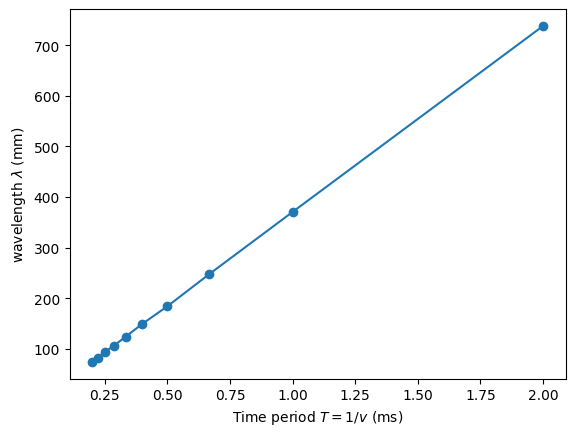

In [21]:
plot(1/df["v"],df["lambda"],'-o')
xlabel("Time period $T=1/v$ (ms)")
ylabel(r"wavelength $\lambda $ (mm)")

In [22]:
df["lambda"] = array(df["lambda"].values,dtype='i')
df["V"] = array(df["V"].values,dtype='i')
df.to_excel("Data.xlsx")

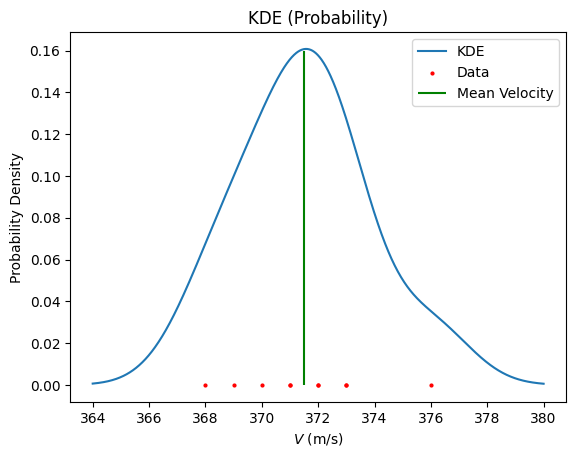

In [23]:
df["V"].plot.kde()
title("KDE (Probability)")
xlabel("$V$ (m/s)")
ylabel("Probability Density")
scatter(df["V"],df["V"].values*0,s=4,c='red')
vlines(mean(df['V']),0,0.16,colors=['green'])
legend(["KDE",'Data',"Mean Velocity"])

In [24]:
LC = 1
LCf = 0.001
lce = 2* mean(df["v"] * LC / (df["n"]-1)) + 2* mean((LCf/2) * (df["X2"]-df["X1"])/(df["n"]-1))
#df["lambda"] = 2*(df["X2"]-df["X1"])/(df["n"]-1) #mm
lce

0.8563455344655344

$$
\Delta_\text{LC}V = \langle \frac{v_n * (\Delta_\text{LC} X_{1,n} + \Delta_\text{LC} X_{2,n})}{n} \rangle\approx 0.374 \text{m/s}
$$

In [26]:
y = (lce**2)/12
x = var(df["V"])
(x+y)**0.5

2.1705093041803014